## 02 Feature Engineering

A 24 hour prediction window offer a practical balance between accuracy and usefulness. It give maintenance teams enough time to react, to schedule service and to minimze production losses. The main goal will be to anticipate failures one day before they happen.

In this notebook, we will present the feature engineering strategy requiered to build such predictive model. The main idea is to generate time-aware features that capture both the recent behavior of each machine and the longer trends.

To train the models, we will consider a multiclass target (`comp1`, `comp2`, `comp3`, `comp4`). Each time a component fails, It will be marked the 24 hours before the event as a risk window. In addition, we will keep a binary version of the label that can be useful for alerting purposes. 

## 2.1 Data Load

We will load data, enforce consistent types and run light checks. 

In [74]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [80]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

In [4]:
FILES = {
    "telemetry": RAW_DIR / "PdM_telemetry.csv",
    "errors":    RAW_DIR / "PdM_errors.csv",
    "maint":     RAW_DIR / "PdM_maint.csv",
    "failures":  RAW_DIR / "PdM_failures.csv",
    "machines":  RAW_DIR / "PdM_machines.csv",
}

In [ ]:
# Check for missing files
missing = [k for k, p in FILES.items() if not p.exists()]
if missing:
    raise FileNotFoundError(
        f"Missing raw files for keys: {missing}. "
        f"Expected at: {RAW_DIR.resolve()}"
    )

In [6]:
telemetry = pd.read_csv(FILES["telemetry"], parse_dates=["datetime"])
errors    = pd.read_csv(FILES["errors"],    parse_dates=["datetime"])
maint     = pd.read_csv(FILES["maint"],     parse_dates=["datetime"])
failures  = pd.read_csv(FILES["failures"],  parse_dates=["datetime"])
machines  = pd.read_csv(FILES["machines"])

In [20]:
# Peek few rows 
display(telemetry.head(3), telemetry.dtypes)
display(errors.head(3), errors.dtypes)
display(maint.head(3), maint.dtypes)
display(failures.head(3), failures.dtypes)
display(machines.head(3), machines.dtypes)

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847


datetime     datetime64[ns]
machineID             int64
volt                float64
rotate              float64
pressure            float64
vibration           float64
dtype: object

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5


datetime     datetime64[ns]
machineID             int64
errorID              object
dtype: object

,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3


datetime     datetime64[ns]
machineID             int64
comp                 object
dtype: object

,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2


datetime     datetime64[ns]
machineID             int64
failure              object
dtype: object

,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8


machineID     int64
model        object
age           int64
dtype: object

## 2.2 Time Normalization

In order to integrate multiple data sources, we need a common time axis and consistent keys. The predictive maintenance dataset is organized aounrd two identifiers:
* `datetime`: Timestamps of observations
* `machineID`: Unique machine identifier

Nevertheless, the data sources differ in their structure:
* Telemetry provides hourly records for each machine.
* Errors, maintenance and failers are stored as event logs. These need to be aligned with the telemetry timeline.

The following steps includes:
* Hourly grid as standard. We normalize all events to the hourly resolution of telmetry. 
* The pair `machineID` and `datetime` will be used as the primery key for joining.
* If no error/maintenance/failure occurs at a given hour, the event columns remain empty encoded as 0. 

In [21]:
tmin, tmax = telemetry["datetime"].min(), telemetry["datetime"].max()
print(f"Telemetry timeline: min = {tmin} to max = {tmax}")

Telemetry timeline: min = 2015-01-01 06:00:00 to max = 2016-01-01 06:00:00


In [22]:
machines_list = machines["machineID"].unique()
hourly_index = pd.date_range(start=tmin, end=tmax, freq="1H")

/var/folders/jq/v582t6wn3j94_fn95w6_4w9r0000gn/T/ipykernel_92245/2731731415.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_index = pd.date_range(start=tmin, end=tmax, freq="1H")


In [23]:
grid = (
    pd.MultiIndex.from_product([machines_list, hourly_index],
                               names=["machineID", "datetime"])
    .to_frame(index=False)
)

In [24]:
grid.head()

,machineID,datetime
0,1,2015-01-01 06:00:00
1,1,2015-01-01 07:00:00
2,1,2015-01-01 08:00:00
3,1,2015-01-01 09:00:00
4,1,2015-01-01 10:00:00


## 2.3 Telemetry Features

The raw telemetry provides sensor readings on the specific time, but models perform better when capture temporal patterns. On the this section, rolling statistics are calculated over a fixed window of hours:
* The 24 hour rolling window is selected. This time should be long enough to smooth noise but short to capture changes before failure.
* For each telemetry signal, the mean and standard deviation are calculated.

In [27]:
# Merge telemetry with the corresponding grid
df = grid.merge(telemetry, on=["machineID", "datetime"], how="left")

In [28]:
df.head()

,machineID,datetime,volt,rotate,pressure,vibration
0,1,2015-01-01 06:00:00,176.217853,418.504078,113.077935,45.087686
1,1,2015-01-01 07:00:00,162.879223,402.747490,95.460525,43.413973
2,1,2015-01-01 08:00:00,170.989902,527.349825,75.237905,34.178847
3,1,2015-01-01 09:00:00,162.462833,346.149335,109.248561,41.122144
4,1,2015-01-01 10:00:00,157.610021,435.376873,111.886648,25.990511


In [29]:
telemetry_cols = ["volt", "rotate", "pressure", "vibration"]

# For each machine, compute rolling stats (24h window)
df = df.sort_values(["machineID", "datetime"])

for col in telemetry_cols:
    df[f"{col}_mean_24h"] = (
        df.groupby("machineID")[col]
          .transform(lambda x: x.rolling(window=24, min_periods=1).mean())
    )
    df[f"{col}_std_24h"] = (
        df.groupby("machineID")[col]
          .transform(lambda x: x.rolling(window=24, min_periods=1).std())
    )

Telemetry features added: ['volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h']


In [31]:
df.head()

,machineID,datetime,volt,rotate,pressure,vibration,volt_mean_24h,volt_std_24h,rotate_mean_24h,rotate_std_24h,pressure_mean_24h,pressure_std_24h,vibration_mean_24h,vibration_std_24h
0,1,2015-01-01 06:00:00,176.217853,418.504078,113.077935,45.087686,176.217853,NaN,418.504078,NaN,113.077935,NaN,45.087686,NaN
1,1,2015-01-01 07:00:00,162.879223,402.747490,95.460525,43.413973,169.548538,9.431836,410.625784,11.141591,104.269230,12.457390,44.250829,1.183494
2,1,2015-01-01 08:00:00,170.989902,527.349825,75.237905,34.178847,170.028993,6.721032,449.533798,67.849599,94.592122,18.934956,40.893502,5.874970
3,1,2015-01-01 09:00:00,162.462833,346.149335,109.248561,41.122144,168.137453,6.665324,423.687682,75.770259,98.256232,17.109194,40.950662,4.798255
4,1,2015-01-01 10:00:00,157.610021,435.376873,111.886648,25.990511,166.031967,7.448844,426.025520,65.826868,100.982315,16.021893,37.958632,7.875828


## 2.4 Error Log Features

In `errors` we have the error codes for each machine. These error are important for early warning indicators. Since machines can have multiple error over time, it is important to treat them as a categorical event. The following section includes:
* Treatment of errors as categorical events.
* In order to ensure temporal consistency, we use a 24-hour rolling window to record errors. For each error, it is computed the count of occurences within the last 24 hours.

High error counts in short periods often signal that a component is about to fail. 

In [32]:
errors.head()

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


In [37]:
error_pivot = (
    errors.assign(flag=1)
          .pivot_table(index=["datetime", "machineID"], 
                       columns="errorID", values="flag", fill_value=0)
          .reset_index()
)

error_pivot.head()

errorID,datetime,machineID,error1,error2,error3,error4,error5
0,2015-01-01 06:00:00,24,1.0,0.0,0.0,0.0,0.0
1,2015-01-01 06:00:00,73,0.0,0.0,0.0,1.0,0.0
2,2015-01-01 06:00:00,81,1.0,0.0,0.0,0.0,0.0
3,2015-01-01 07:00:00,43,0.0,0.0,1.0,0.0,0.0
4,2015-01-01 08:00:00,14,0.0,0.0,0.0,1.0,0.0


In [39]:
df = df.merge(error_pivot, on=["machineID", "datetime"], how="left")
df.fillna({col: 0 for col in error_pivot.columns if col not in ["datetime", "machineID"]}, inplace=True)
df.head()

,machineID,datetime,volt,rotate,pressure,vibration,volt_mean_24h,volt_std_24h,rotate_mean_24h,rotate_std_24h,pressure_mean_24h,pressure_std_24h,vibration_mean_24h,vibration_std_24h,error1,error2,error3,error4,error5
0,1,2015-01-01 06:00:00,176.217853,418.504078,113.077935,45.087686,176.217853,NaN,418.504078,NaN,113.077935,NaN,45.087686,NaN,0.0,0.0,0.0,0.0,0.0
1,1,2015-01-01 07:00:00,162.879223,402.747490,95.460525,43.413973,169.548538,9.431836,410.625784,11.141591,104.269230,12.457390,44.250829,1.183494,0.0,0.0,0.0,0.0,0.0
2,1,2015-01-01 08:00:00,170.989902,527.349825,75.237905,34.178847,170.028993,6.721032,449.533798,67.849599,94.592122,18.934956,40.893502,5.874970,0.0,0.0,0.0,0.0,0.0
3,1,2015-01-01 09:00:00,162.462833,346.149335,109.248561,41.122144,168.137453,6.665324,423.687682,75.770259,98.256232,17.109194,40.950662,4.798255,0.0,0.0,0.0,0.0,0.0
4,1,2015-01-01 10:00:00,157.610021,435.376873,111.886648,25.990511,166.031967,7.448844,426.025520,65.826868,100.982315,16.021893,37.958632,7.875828,0.0,0.0,0.0,0.0,0.0


In [40]:
# Rolling count of errors over past 24h
error_cols = [c for c in df.columns if "error" in c]

for col in error_cols:
    df[f"{col}_count_24h"] = (
        df.groupby("machineID")[col]
          .transform(lambda x: x.rolling(window=24, min_periods=1).sum())
    )

In [41]:
df.head()

,machineID,datetime,volt,rotate,pressure,vibration,volt_mean_24h,volt_std_24h,rotate_mean_24h,rotate_std_24h,...,error1,error2,error3,error4,error5,error1_count_24h,error2_count_24h,error3_count_24h,error4_count_24h,error5_count_24h
0,1,2015-01-01 06:00:00,176.217853,418.504078,113.077935,45.087686,176.217853,NaN,418.504078,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2015-01-01 07:00:00,162.879223,402.747490,95.460525,43.413973,169.548538,9.431836,410.625784,11.141591,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2015-01-01 08:00:00,170.989902,527.349825,75.237905,34.178847,170.028993,6.721032,449.533798,67.849599,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,2015-01-01 09:00:00,162.462833,346.149335,109.248561,41.122144,168.137453,6.665324,423.687682,75.770259,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,2015-01-01 10:00:00,157.610021,435.376873,111.886648,25.990511,166.031967,7.448844,426.025520,65.826868,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2.5 Maintenance Features

Maintenance dataset indicates when a component was replaced. An interesting feature is the time since last replacement. On this section the raw maintenance events is converted on four continuous features (one per component) that measure days since last replacement. 

In [42]:
maint.head()

,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4


In [48]:
comp_cols

['comp1', 'comp2', 'comp3', 'comp4']

In [51]:
# One-hot encoding for comp feature
maint_oh = (
    pd.get_dummies(maint, columns=["comp"])
      .rename(columns=lambda c: c.replace("comp_", ""))
)

# Component columns detected 
comp_cols = [c for c in maint_oh.columns if c.startswith("comp")]

# Group per hour
maint_hourly = (
    maint_oh.groupby(["machineID","datetime"])[comp_cols]
            .sum()
            .reset_index()
)

maint_hourly.head()

,machineID,datetime,comp1,comp2,comp3,comp4
0,1,2014-06-01 06:00:00,0,1,0,0
1,1,2014-07-16 06:00:00,0,0,0,1
2,1,2014-07-31 06:00:00,0,0,1,0
3,1,2014-12-13 06:00:00,1,0,0,0
4,1,2015-01-05 06:00:00,1,0,0,1


In [52]:
# Merge onto the full hourly grid
maint_grid = (
    grid.merge(maint_hourly, on=["machineID","datetime"], how="left")
        .sort_values(["machineID","datetime"])
)

# Replace no events with zero
maint_grid[comp_cols] = maint_grid[comp_cols].fillna(0)

In [53]:
for c in comp_cols:
    # Indicates the timestampt when a replacement ocurrs otherwise NaN
    event_ts = maint_grid["datetime"].where(maint_grid[c] >= 1, pd.NaT)

    # Forward-fill the last replacement timestampt per machine
    last_rep = (
        maint_grid.assign(_evt=event_ts)
                  .groupby("machineID")["_evt"]
                  .ffill()
    )

    # Compute days since replacement
    maint_grid[c] = (maint_grid["datetime"] - last_rep).dt.total_seconds() / 86400.0

In [55]:
maint_feats = maint_grid[["machineID","datetime"] + comp_cols]
df = df.merge(maint_feats, on=["machineID","datetime"], how="left")
df.head()

,machineID,datetime,volt,rotate,pressure,vibration,volt_mean_24h,volt_std_24h,rotate_mean_24h,rotate_std_24h,...,error5,error1_count_24h,error2_count_24h,error3_count_24h,error4_count_24h,error5_count_24h,comp1,comp2,comp3,comp4
0,1,2015-01-01 06:00:00,176.217853,418.504078,113.077935,45.087686,176.217853,NaN,418.504078,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,1,2015-01-01 07:00:00,162.879223,402.747490,95.460525,43.413973,169.548538,9.431836,410.625784,11.141591,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,1,2015-01-01 08:00:00,170.989902,527.349825,75.237905,34.178847,170.028993,6.721032,449.533798,67.849599,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,1,2015-01-01 09:00:00,162.462833,346.149335,109.248561,41.122144,168.137453,6.665324,423.687682,75.770259,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
4,1,2015-01-01 10:00:00,157.610021,435.376873,111.886648,25.990511,166.031967,7.448844,426.025520,65.826868,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


## 2.6 Machine Features

Every machine is not identical. If two machine run under the same condition, their design and operational history is important. In this section, the feature set is enrich with static attributes including:
* model
* age

By integrating these attributes, we provide the model with context that explain why some machines may fail sooner than others.

In [56]:
machines.head()

,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


In [57]:
df = df.merge(machines[["machineID", "model", "age"]], on="machineID", how="left")
df.head()

,machineID,datetime,volt,rotate,pressure,vibration,volt_mean_24h,volt_std_24h,rotate_mean_24h,rotate_std_24h,...,error2_count_24h,error3_count_24h,error4_count_24h,error5_count_24h,comp1,comp2,comp3,comp4,model,age
0,1,2015-01-01 06:00:00,176.217853,418.504078,113.077935,45.087686,176.217853,NaN,418.504078,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,model3,18
1,1,2015-01-01 07:00:00,162.879223,402.747490,95.460525,43.413973,169.548538,9.431836,410.625784,11.141591,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,model3,18
2,1,2015-01-01 08:00:00,170.989902,527.349825,75.237905,34.178847,170.028993,6.721032,449.533798,67.849599,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,model3,18
3,1,2015-01-01 09:00:00,162.462833,346.149335,109.248561,41.122144,168.137453,6.665324,423.687682,75.770259,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,model3,18
4,1,2015-01-01 10:00:00,157.610021,435.376873,111.886648,25.990511,166.031967,7.448844,426.025520,65.826868,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,model3,18


In [60]:
# Check if there are missing values on model and age
missing_model = df["model"].isna().sum()
missing_age   = df["age"].isna().sum()
print(f"Missing Models: {missing_model}, Missing Age: {missing_age}")

Missing Models: 0, Missing Age: 0


## 2.7 Label contructions

For the moment, we have a dataset which provides failures log that specifies the component and timestampt of each breackdown. On this section, two target variables are created:
* `failure which indicates whether a machine is within a 24h failer.
* `failure_comp` which describe the failed component including a `None` value for normal operation. 

In [63]:
failures.head()

,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4


In [69]:
labels = df[["machineID", "datetime"]].copy()


labels["failure_binary"] = 0
labels["failure_comp"]   = "none"

fail_ev = failures.rename(columns={"datetime": "fail_datetime"}).copy()

In [70]:
fail_ev = fail_ev.sort_values(["machineID", "fail_datetime"]).reset_index(drop=True)
labels  = labels.sort_values(["machineID", "datetime"]).reset_index(drop=True)

for m_id, grp in fail_ev.groupby("machineID"):
    idx_m = labels.index[labels["machineID"] == m_id]
    lab_m = labels.loc[idx_m]

    for _, row in grp.iterrows():
        f_time = row["fail_datetime"]
        comp   = row["failure"]  # component name in the failures file

        # 24h pre-failure window: [f_time - 24h, f_time)
        start = f_time - pd.Timedelta(hours=24)
        mask  = (lab_m["datetime"] >= start) & (lab_m["datetime"] < f_time)

        # apply labels on the machine slice, then write back to main frame
        lab_m.loc[mask, "failure_binary"] = 1
        lab_m.loc[mask, "failure_comp"]   = str(comp)

    labels.loc[idx_m, ["failure_binary", "failure_comp"]] = lab_m[["failure_binary", "failure_comp"]].values

labels["failure_comp"] = labels["failure_comp"].astype("category")

failure_binary
0    858916
1     17184
Name: count, dtype: int64


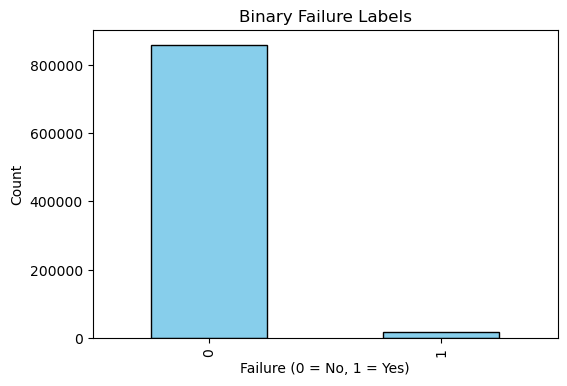

failure_comp
none     858916
comp2      5754
comp4      4287
comp1      4104
comp3      3039
Name: count, dtype: int64


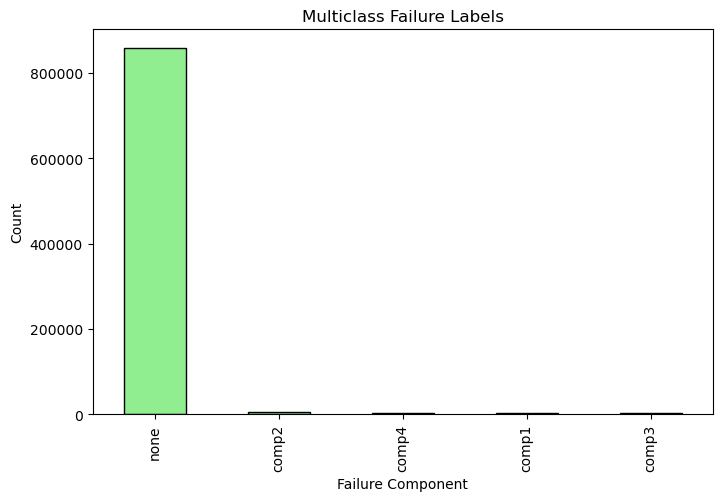

In [76]:
# Binary label counts
binary_counts = labels["failure_binary"].value_counts(dropna=False)
print(binary_counts)
plt.figure(figsize=(6,4))
binary_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Binary Failure Labels")
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Multiclass label counts
multiclass_counts = labels["failure_comp"].value_counts(dropna=False)
print(multiclass_counts)
plt.figure(figsize=(8,5))
multiclass_counts.plot(kind="bar", color="lightgreen", edgecolor="black")
plt.title("Multiclass Failure Labels")
plt.xlabel("Failure Component")
plt.ylabel("Count")
plt.show()

In [77]:
labels

,machineID,datetime,failure_binary,failure_comp
0,1,2015-01-01 06:00:00,0,none
1,1,2015-01-01 07:00:00,0,none
2,1,2015-01-01 08:00:00,0,none
3,1,2015-01-01 09:00:00,0,none
4,1,2015-01-01 10:00:00,0,none
...,...,...,...,...
876095,100,2016-01-01 02:00:00,0,none
876096,100,2016-01-01 03:00:00,0,none
876097,100,2016-01-01 04:00:00,0,none
876098,100,2016-01-01 05:00:00,0,none


# 2.8 Final Merge and Storing

This section provide the final merge between features and labels. 

In [78]:
dataset = df.merge(
    labels[["machineID", "datetime", "failure_binary", "failure_comp"]],
    on=["machineID", "datetime"],
    how="left"   
)

dataset.head()

,machineID,datetime,volt,rotate,pressure,vibration,volt_mean_24h,volt_std_24h,rotate_mean_24h,rotate_std_24h,...,error4_count_24h,error5_count_24h,comp1,comp2,comp3,comp4,model,age,failure_binary,failure_comp
0,1,2015-01-01 06:00:00,176.217853,418.504078,113.077935,45.087686,176.217853,NaN,418.504078,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,model3,18,0,none
1,1,2015-01-01 07:00:00,162.879223,402.747490,95.460525,43.413973,169.548538,9.431836,410.625784,11.141591,...,0.0,0.0,NaN,NaN,NaN,NaN,model3,18,0,none
2,1,2015-01-01 08:00:00,170.989902,527.349825,75.237905,34.178847,170.028993,6.721032,449.533798,67.849599,...,0.0,0.0,NaN,NaN,NaN,NaN,model3,18,0,none
3,1,2015-01-01 09:00:00,162.462833,346.149335,109.248561,41.122144,168.137453,6.665324,423.687682,75.770259,...,0.0,0.0,NaN,NaN,NaN,NaN,model3,18,0,none
4,1,2015-01-01 10:00:00,157.610021,435.376873,111.886648,25.990511,166.031967,7.448844,426.025520,65.826868,...,0.0,0.0,NaN,NaN,NaN,NaN,model3,18,0,none


In [81]:
dataset_path = PROCESSED_DIR / "dataset.csv"
dataset.to_csv(dataset_path, index=False)